https://dlo.mijnhva.nl/d2l/le/content/691830/viewContent/2753548/View

# Methoden en Technieken -- Blok 2

## Datapunt 2a,

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en
technische requirements** op.
- B1: Je **verkent en prepareert een dataset voor het trainen en testen van een AI-model en
kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen**, rekening
houdend met technische en ethische randvoorwaarden.
- B2: Je **stelt op basis van requirements en data een geschikte architectuur voor een AI-
oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld**
machine learning, **deep learning**, kennisrepresentatie, computer vision en **natural language
processing**.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch
proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability,
explainability, **model complexity** en resource demand.

Dit is een individuele opdracht. Het is toegestaan met elkaar de opdracht te bespreken, maar iedereen schrijft zijn eigen code en antwoorden. Mocht je code van het internet hebben overgenomen/aangepast, vermeld dan de bron in het commentaar. Het gebruik van generatieve AI (Chat-GPT, etc...) is *alleen* toegestaan bij de voorbereiding op de opdracht. Denk hierbj aan activiteiten zoals brainstormen, of het maken van een plan. Het is niet toegestaan code of tekst van generative AI over te nemen. (Level 2 van de AI Assessment Scale)


In [77]:
import os
os.environ["KERAS_BACKEND"] = "torch" # Has to be set before importing keras otherwise it can't be set anymore

import random
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import ops
import tensorflow as tf

import pickle
import numpy as np

import string
import re
import math

random.seed(67)
np.random.seed(67)
tf.random.set_seed(67)

In [78]:
DATA_PATH = "nld-eng/nld.txt"
MODEL_DIR = "models"


## De opdracht

In de slides van les 3 staat hoe een Engels - Nederlands vertaalmodel gemaakt wordt met een transformer-encoder en -decoder.

### Deel 1
#### Deel 1a
Maak dit model na en fit dit model.

#### Load data

In [79]:
with open(DATA_PATH, "r", encoding="utf8") as f:
    lines = f.read().split("\n")[:-1]

text_pairs = []
for line in lines:
    english, dutch, rest = line.split("\t")
    dutch = "[start] " + dutch + " [end]"
    text_pairs.append((english, dutch))

random.shuffle(text_pairs)

print("\nTotal number of sentence pairs:", len(text_pairs))
print("Example pair:", random.choice(text_pairs))


Total number of sentence pairs: 83864
Example pair: ("This fruit doesn't taste good.", '[start] Dit fruit smaakt niet goed. [end]')


#### Split dat

In [80]:
val_samples = int(0.15 * len(text_pairs))
train_samples = len(text_pairs) - 2 * val_samples

train_pairs = text_pairs[:train_samples]
val_pairs = text_pairs[train_samples : train_samples + val_samples]
test_pairs = text_pairs[train_samples + val_samples :]

print(f"Train pairs: {len(train_pairs)}")
print(f"Val   pairs: {len(val_pairs)}")
print(f"Test  pairs: {len(test_pairs)}")

Train pairs: 58706
Val   pairs: 12579
Test  pairs: 12579


#### Data exploration

In [81]:
print(random.choice(train_pairs))

def sentence_lengths(pairs):
    en_lengths = [len(p[0].split()) for p in pairs]
    nl_lengths = [len(p[1].split()) for p in pairs]
    return en_lengths, nl_lengths

train_en_lengths, train_nl_lengths = sentence_lengths(train_pairs)
print("\nAverage English length in train:", sum(train_en_lengths) / len(train_en_lengths))
print("Average Dutch length in train  :", sum(train_nl_lengths) / len(train_nl_lengths))

('There was a bus schedule on the wall.', '[start] Er hing een busdienstregeling op de muur. [end]')

Average English length in train: 5.721595748305114
Average Dutch length in train  : 7.964688447518141


In [82]:
# Duplicate source sentences: show a few conflicts and total count
from collections import defaultdict
import itertools

pairs = []
if 'train_pairs' in globals() and isinstance(train_pairs, list):
    pairs += train_pairs
if 'val_pairs' in globals() and isinstance(val_pairs, list):
    pairs += val_pairs

src_to_tgts = defaultdict(set)
for src, tgt in pairs:
    s, t = src.strip(), tgt.strip()
    if s and t:
        src_to_tgts[s].add(t)

conflicts = {s: list(ts) for s, ts in src_to_tgts.items() if len(ts) > 1}
print(f"Conflicting source sentences: {len(conflicts)}")

for s, ts in itertools.islice(conflicts.items(), 5):
    print("\nSource:", s)
    for t in ts:
        print("  -", t)


Conflicting source sentences: 8186

Source: My name is Tom.
  - [start] Mijn naam is Tom. [end]
  - [start] Ik heet Tom. [end]

Source: I'm bored.
  - [start] Ik verveel me. [end]
  - [start] Ik verveel mij. [end]

Source: She was injured in the traffic accident.
  - [start] Ze raakte gewond bij het verkeersongeval. [end]
  - [start] Zij raakte gewond bij het verkeersongeval. [end]

Source: We stopped working.
  - [start] Wij zijn gestopt met het werk. [end]
  - [start] We zijn gestopt met het werk. [end]

Source: The lecture was really boring.
  - [start] De lezing was erg saai. [end]
  - [start] De lezing was echt saai. [end]


Dutch sentences: 71285; mean=7.56; median=7.00
English sentences: 71285; mean=6.11; median=6.00


C:\Users\Frank\AppData\Local\Temp\ipykernel_16960\1883559949.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot([nl_lengths, en_lengths], labels=['Dutch', 'English'])


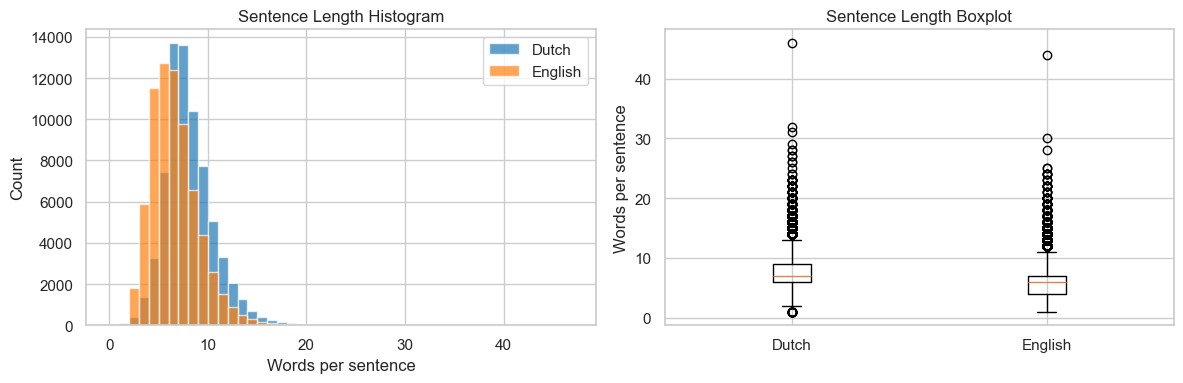

In [83]:
# Sentence length distributions by language
import matplotlib.pyplot as plt
import numpy as np

def sentence_lengths(texts):
    return [len(t.strip().split()) for t in texts if isinstance(t, str)]

nl_texts = []
en_texts = []

# Prefer provided lists; otherwise derive from pairs
if 'train_dutch_texts' in globals() and isinstance(train_dutch_texts, list):
    nl_texts.extend(train_dutch_texts)
if 'val_pairs' in globals() and isinstance(val_pairs, list):
    nl_texts.extend([p[0] for p in val_pairs])
if 'train_english_texts' in globals() and isinstance(train_english_texts, list):
    en_texts.extend(train_english_texts)
if 'val_pairs' in globals() and isinstance(val_pairs, list):
    en_texts.extend([p[1] for p in val_pairs])

nl_lengths = sentence_lengths(nl_texts)
en_lengths = sentence_lengths(en_texts)

print(f"Dutch sentences: {len(nl_lengths)}; mean={np.mean(nl_lengths):.2f}; median={np.median(nl_lengths):.2f}")
print(f"English sentences: {len(en_lengths)}; mean={np.mean(en_lengths):.2f}; median={np.median(en_lengths):.2f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
bins = np.arange(0, max(nl_lengths + en_lengths)+2)
axs[0].hist(nl_lengths, bins=bins, alpha=0.7, label='Dutch', color='tab:blue')
axs[0].hist(en_lengths, bins=bins, alpha=0.7, label='English', color='tab:orange')
axs[0].set_title('Sentence Length Histogram')
axs[0].set_xlabel('Words per sentence')
axs[0].set_ylabel('Count')
axs[0].legend()

axs[1].boxplot([nl_lengths, en_lengths], labels=['Dutch', 'English'])
axs[1].set_title('Sentence Length Boxplot')
axs[1].set_ylabel('Words per sentence')

plt.tight_layout()
plt.show()

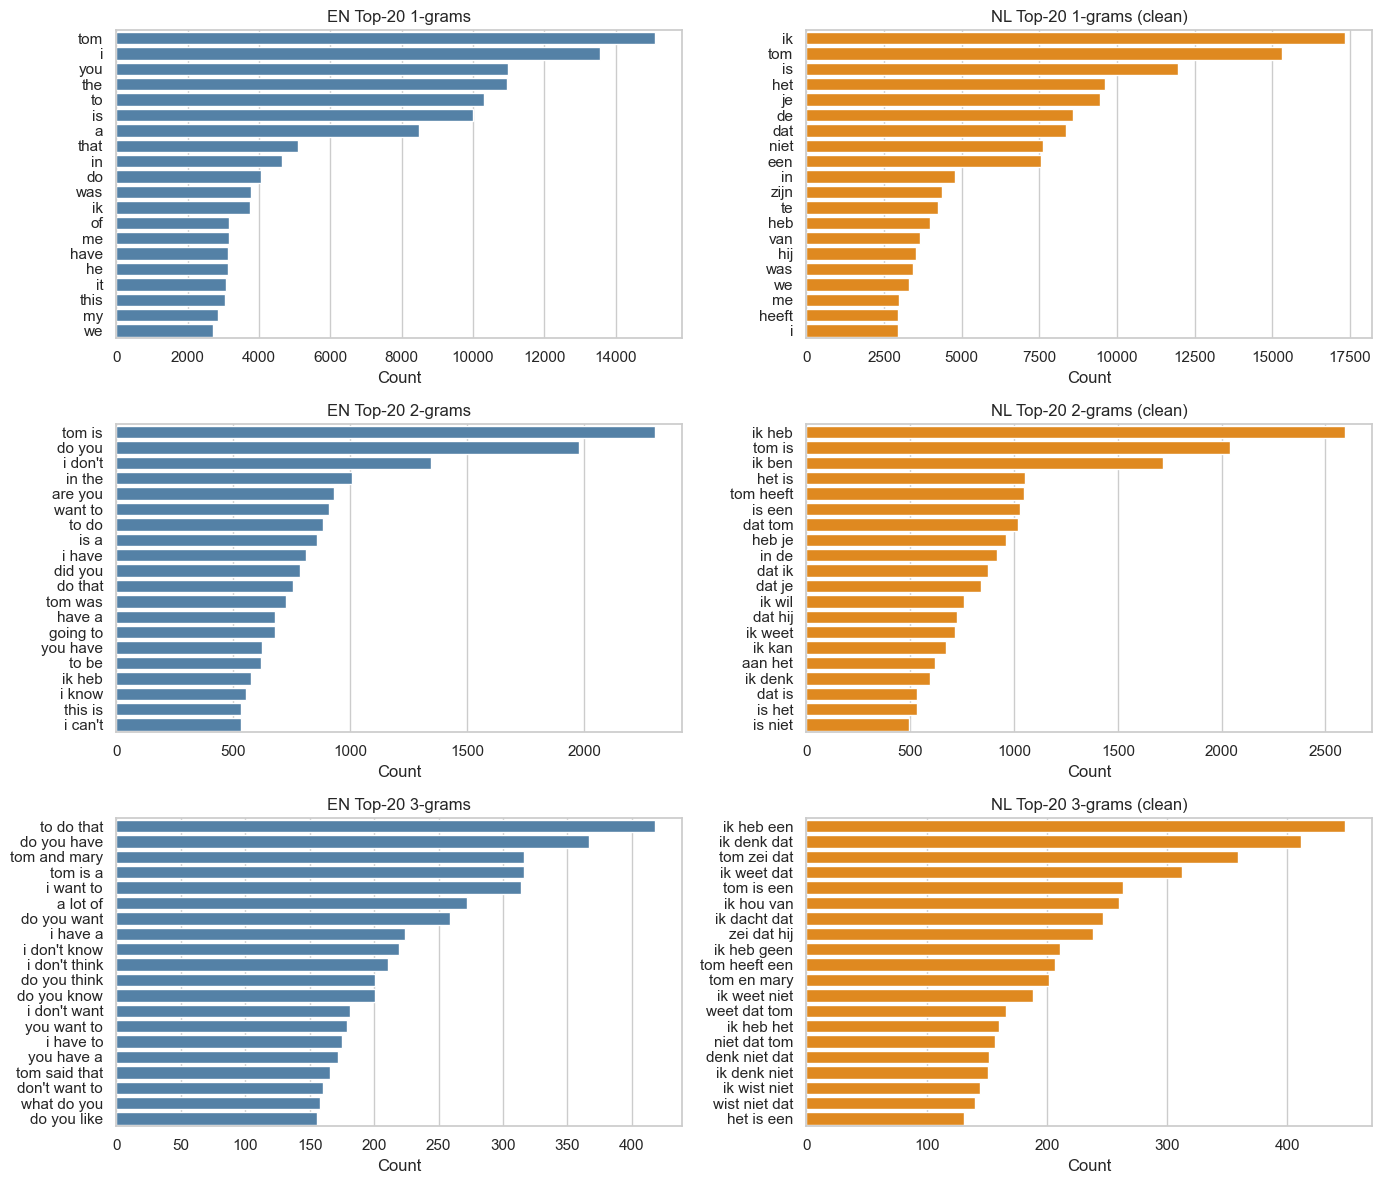

Lexical Diversity (EN) - TTR: 0.0373, Herdan's C: 0.7456
Lexical Diversity (NL clean) - TTR: 0.0425, Herdan's C: 0.7562


In [84]:
# 4) N-grams and Lexical Diversity (TTR, Herdan's C)
def lexical_diversity(tokens):
    types = len(set(tokens))
    tokens_n = len(tokens)
    ttr = types / tokens_n if tokens_n else 0.0
    herdan_c = (math.log(types+1) / math.log(tokens_n+1)) if tokens_n else 0.0
    return ttr, herdan_c

# Reuse filtered token lists from Zipf section if available; else compute here
def ensure_tokens(texts):
    toks = [simple_tokenize(t) for t in texts]
    return [t for t in flatten(toks) if t not in {"start", "end"}]

if 'en_flat' not in globals() or 'nl_flat' not in globals():
    en_flat = ensure_tokens(EN)
    nl_flat = ensure_tokens(NL)

# Prepare per-sentence filtered tokens for n-grams
en_tokens_clean = [[t for t in toks if t not in {"start", "end"}] for toks in [simple_tokenize(t) for t in EN]]
nl_tokens_clean = [[t for t in toks if t not in {"start", "end"}] for toks in [simple_tokenize(t) for t in NL]]

N_values = [1,2,3]
en_ngram_freqs = {}
nl_ngram_freqs = {}
for N in N_values:
    en_ngrams = flatten([ngrams(toks, N) for toks in en_tokens_clean])
    nl_ngrams = flatten([ngrams(toks, N) for toks in nl_tokens_clean])
    en_ngram_freqs[N] = Counter(en_ngrams)
    nl_ngram_freqs[N] = Counter(nl_ngrams)

top_k = 20
fig, axs = plt.subplots(len(N_values), 2, figsize=(14, 4*len(N_values)))
for idx, N in enumerate(N_values):
    en_top = en_ngram_freqs[N].most_common(top_k)
    nl_top = nl_ngram_freqs[N].most_common(top_k)
    en_labels = [' '.join(t) if isinstance(t, tuple) else t for t,_ in en_top]
    en_counts = [c for _,c in en_top]
    nl_labels = [' '.join(t) if isinstance(t, tuple) else t for t,_ in nl_top]
    nl_counts = [c for _,c in nl_top]

    sns.barplot(x=en_counts, y=en_labels, ax=axs[idx,0], color='steelblue')
    axs[idx,0].set_title(f'EN Top-{top_k} {N}-grams')
    axs[idx,0].set_xlabel('Count')
    axs[idx,0].set_ylabel('')

    sns.barplot(x=nl_counts, y=nl_labels, ax=axs[idx,1], color='darkorange')
    axs[idx,1].set_title(f'NL Top-{top_k} {N}-grams (clean)')
    axs[idx,1].set_xlabel('Count')
    axs[idx,1].set_ylabel('')

plt.tight_layout()
plt.show()

en_ttr, en_herdan = lexical_diversity(en_flat)
nl_ttr, nl_herdan = lexical_diversity(nl_flat)
print(f"Lexical Diversity (EN) - TTR: {en_ttr:.4f}, Herdan's C: {en_herdan:.4f}")
print(f"Lexical Diversity (NL clean) - TTR: {nl_ttr:.4f}, Herdan's C: {nl_herdan:.4f}")

EN vocab size: 15,331; NL vocab size (clean): 17,949


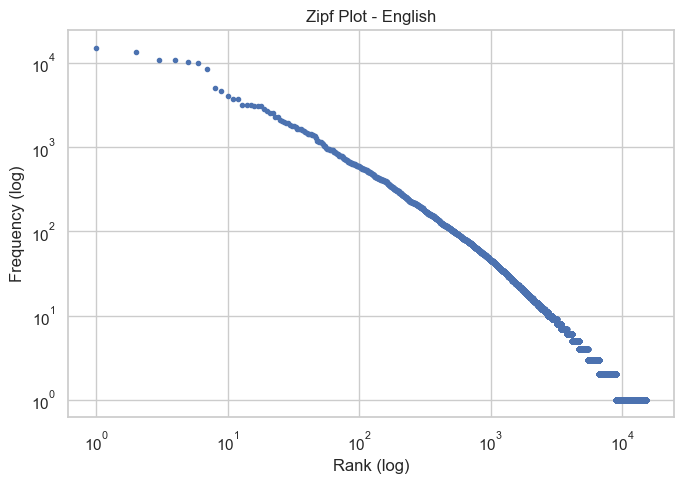

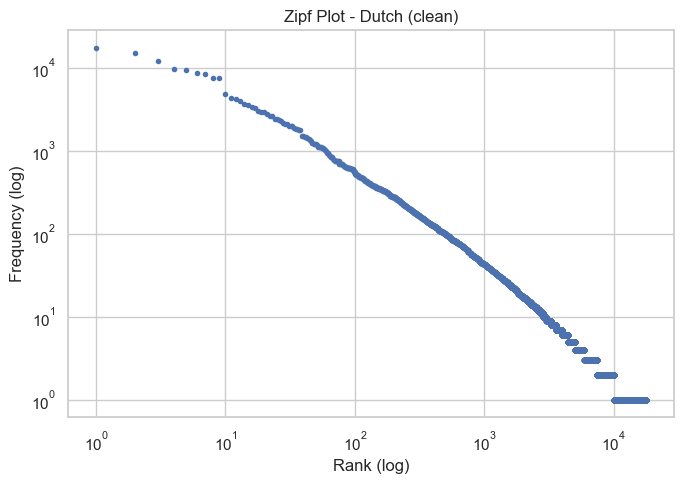

Top EN tokens: [('tom', 15110), ('i', 13572), ('you', 10986), ('the', 10960), ('to', 10309), ('is', 9995), ('a', 8489), ('that', 5096), ('in', 4651), ('do', 4063), ('was', 3787), ('ik', 3746), ('of', 3166), ('me', 3152), ('have', 3143), ('he', 3125), ('it', 3088), ('this', 3052), ('my', 2859), ('we', 2704), ("don't", 2544), ('are', 2540), ("i'm", 2301), ('your', 2263), ('het', 2096)]
Top NL tokens (clean): [('ik', 17352), ('tom', 15300), ('is', 11974), ('het', 9622), ('je', 9449), ('de', 8584), ('dat', 8354), ('niet', 7615), ('een', 7555), ('in', 4800), ('zijn', 4382), ('te', 4249), ('heb', 3977), ('van', 3667), ('hij', 3521), ('was', 3419), ('we', 3302), ('me', 2987), ('heeft', 2962), ('i', 2943), ('mijn', 2753), ('op', 2645), ('wat', 2638), ('er', 2429), ('ben', 2422)]


In [85]:
# 3) Zipf Plots + Top tokens (EN + NL clean)
en_tokens = [simple_tokenize(t) for t in EN]
nl_tokens = [simple_tokenize(t) for t in NL]
# Filter out artificial tokens just in case
def filter_artifacts(tok_list):
    return [t for t in tok_list if t not in {"start", "end"}]

en_flat = filter_artifacts(flatten(en_tokens))
nl_flat = filter_artifacts(flatten(nl_tokens))

from collections import Counter
en_freq = Counter(en_flat)
nl_freq = Counter(nl_flat)

print(f"EN vocab size: {len(en_freq):,}; NL vocab size (clean): {len(nl_freq):,}")
zipf_plot(en_freq, 'Zipf Plot - English')
zipf_plot(nl_freq, 'Zipf Plot - Dutch (clean)')

k = 25
print('Top EN tokens:', en_freq.most_common(k))
print('Top NL tokens (clean):', nl_freq.most_common(k))

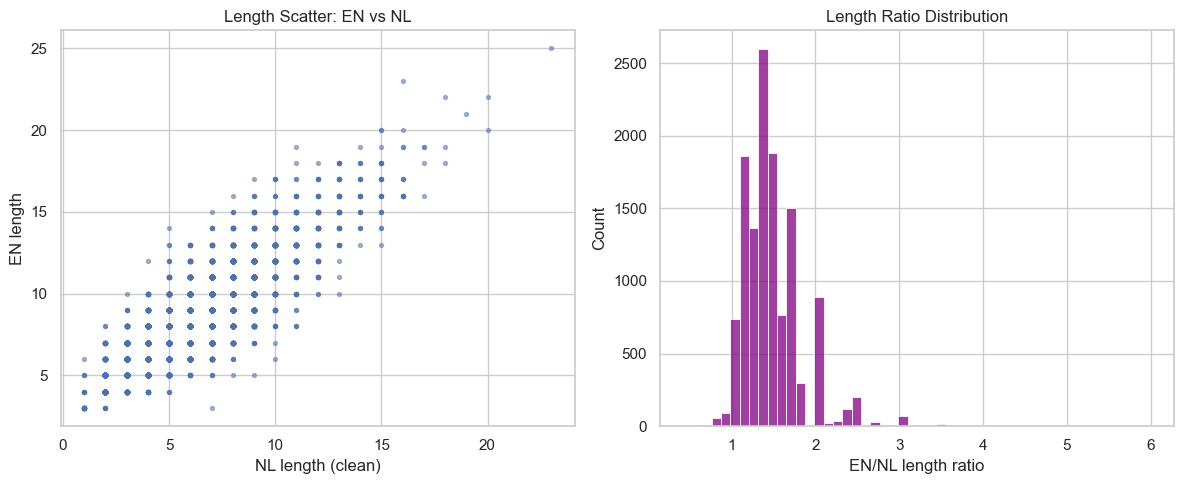

Mean ratio EN/NL: 1.480
Median ratio EN/NL: 1.400
Std ratio EN/NL: 0.358


In [86]:
# 2) Length Ratio Scatter + Histogram
n = min(len(en_len), len(nl_len))
en_l = np.array(en_len[:n])
nl_l = np.array(nl_len[:n])
ratio = en_l / (nl_l + 1e-8)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(nl_l, en_l, s=8, alpha=0.5)
plt.xlabel('NL length (clean)')
plt.ylabel('EN length')
plt.title('Length Scatter: EN vs NL')
plt.grid(True)

plt.subplot(1,2,2)
sns.histplot(ratio, bins=50, color='purple')
plt.xlabel('EN/NL length ratio')
plt.title('Length Ratio Distribution')
plt.tight_layout()
plt.show()

print(f"Mean ratio EN/NL: {ratio.mean():.3f}")
print(f"Median ratio EN/NL: {np.median(ratio):.3f}")
print(f"Std ratio EN/NL: {ratio.std():.3f}")

#### Data pre-processing

In [87]:
vocab_size = 15000
sequence_length = 20

strip_chars = string.punctuation + "¿"
strip_chars = strip_chars.replace("[", "")
strip_chars = strip_chars.replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(
        lowercase, f"[{re.escape(strip_chars)}]", ""
    )

english_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
)

dutch_tokenizer = layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

train_english_texts = [pair[0] for pair in train_pairs]
train_dutch_texts   = [pair[1] for pair in train_pairs]

english_tokenizer.adapt(train_english_texts)
dutch_tokenizer.adapt(train_dutch_texts)

In [88]:
batch_size = 64

def format_dataset(eng, dut):
    eng = english_tokenizer(eng)
    dut = dutch_tokenizer(dut)
    features = {
        "english": eng,
        "dutch": dut[:, :-1],  # decoder input, last tokn is skipped
    }
    labels = dut[:, 1:]
    sample_weights = labels != 0
    return features, labels, sample_weights

def make_dataset(pairs):
    eng_texts, dut_texts = zip(*pairs)
    eng_texts = list(eng_texts)
    dut_texts = list(dut_texts)
    dataset = tf.data.Dataset.from_tensor_slices((eng_texts, dut_texts))
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(format_dataset, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.shuffle(2048).cache().prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_pairs)
val_ds   = make_dataset(val_pairs)

In [89]:
eng_vocab = english_tokenizer.get_vocabulary()
eng_index_lookup = dict(zip(range(len(eng_vocab)), eng_vocab))

dut_vocab = dutch_tokenizer.get_vocabulary()
dut_index_lookup = dict(zip(range(len(dut_vocab)), dut_vocab))

for inputs, targets, rest in train_ds.take(1):
    source_sentence = " ".join(eng_index_lookup[int(i)] for i in inputs['english'][1,])
    target_input_sentence = " ".join(dut_index_lookup[int(i)] for i in inputs['dutch'][1,])
    target_output_sentence = " ".join(dut_index_lookup[int(i)] for i in targets[1,])

print("input  :", source_sentence)
print("target inputs :", target_input_sentence)
print("target outputs:", target_output_sentence)

input  : how long does it take               
target inputs : [start] hoelang duurt dat [end]               
target outputs: hoelang duurt dat [end]                


#### Encoder, Decoder + positonal embedding

In [90]:
class TransformerEncoder(keras.Layer):
    def __init__(self, hidden_dim, intermediate_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        key_dim = hidden_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.self_attention_layernorm = layers.LayerNormalization()
        self.feed_forward_1 = layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2 = layers.Dense(hidden_dim)
        self.feed_forward_layernorm = layers.LayerNormalization()

    def call(self, source, source_mask):
        residual = x = source
        mask = source_mask[:, None, :]
        x = self.self_attention(query=x, key=x, value=x, attention_mask=mask)
        x = x + residual
        x = self.self_attention_layernorm(x)

        residual = x
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x


class TransformerDecoder(keras.Layer):
    def __init__(self, hidden_dim, intermediate_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        key_dim = hidden_dim // num_heads
        self.self_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.self_attention_layernorm = layers.LayerNormalization()
        self.cross_attention = layers.MultiHeadAttention(num_heads, key_dim)
        self.cross_attention_layernorm = layers.LayerNormalization()
        self.feed_forward_1 = layers.Dense(intermediate_dim, activation="relu")
        self.feed_forward_2 = layers.Dense(hidden_dim)
        self.feed_forward_layernorm = layers.LayerNormalization()

    def call(self, target, source, source_mask):
        residual = x = target
        # Causal self-attention on target side
        x = self.self_attention(query=x, key=x, value=x, use_causal_mask=True)
        x = x + residual
        x = self.self_attention_layernorm(x)

        residual = x
        mask = source_mask[:, None, :]
        x = self.cross_attention(
            query=x, key=source, value=source, attention_mask=mask
        )
        x = x + residual
        x = self.cross_attention_layernorm(x)

        residual = x
        x = self.feed_forward_1(x)
        x = self.feed_forward_2(x)
        x = x + residual
        x = self.feed_forward_layernorm(x)
        return x


class PositionalEmbedding(keras.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = layers.Embedding(input_dim, output_dim)
        self.position_embeddings = layers.Embedding(sequence_length, output_dim)

    def call(self, inputs):
        positions = ops.cumsum(ops.ones_like(inputs), axis=-1) - 1
        embedded_tokens = self.token_embeddings(inputs)
        embedded_positions = self.position_embeddings(positions)
        return embedded_tokens + embedded_positions

In [91]:
hidden_dim = 256
intermediate_dim = 2056
num_heads = 8

source = keras.Input(shape=(None,), dtype="int32", name="english")
x = PositionalEmbedding(sequence_length, vocab_size, hidden_dim)(source)
encoder_output = TransformerEncoder(hidden_dim, intermediate_dim, num_heads)(
    source=x,
    source_mask=source != 0,
)

target = keras.Input(shape=(None,), dtype="int32", name="dutch")
x = PositionalEmbedding(sequence_length, vocab_size, hidden_dim)(target)
x = TransformerDecoder(hidden_dim, intermediate_dim, num_heads)(
    target=x,
    source=encoder_output,
    source_mask=source != 0,
)

x = layers.Dropout(0.5)(x)
target_predictions = layers.Dense(vocab_size, activation="softmax")(x)

transformer = keras.Model([source, target], target_predictions)
# transformer.summary()

#### Compile and train

In [92]:
transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)

# Callback: save best WORD-level model by validation loss
word_best_ckpt = keras.callbacks.ModelCheckpoint(
    filepath="models/transformer_word_best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

history = transformer.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[word_best_ckpt],
)
# tussen de 7 en 8 minuten per epoch op laptop met cpu
# tussen de 40 en 50 seconden per epoch op Colab met GPU

# lokaal
transformer.save('models/transformer_versie3.keras')
with open('models/transformer_versie3.hist', 'wb') as file:
    pickle.dump(history.history, file)

Epoch 1/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.3459 - loss: 1.6038
Epoch 1: val_loss improved from None to 0.85702, saving model to models/transformer_word_best.keras

Epoch 1: val_loss improved from None to 0.85702, saving model to models/transformer_word_best.keras
918/918 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - accuracy: 0.4530 - loss: 1.2791 - val_accuracy: 0.6017 - val_loss: 0.8570
Epoch 2/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 61s 66ms/step - accuracy: 0.4530 - loss: 1.2791 - val_accuracy: 0.6017 - val_loss: 0.8570
Epoch 2/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6117 - loss: 0.8255
Epoch 2: val_loss improved from 0.85702 to 0.66805, saving model to models/transformer_word_best.keras

Epoch 2: val_loss improved from 0.85702 to 0.66805, saving model to models/transformer_word_best.keras
918/918 ━━━━━━━━━━━━━━━━━━━━ 57s 62ms/step - accuracy: 0.6330 - loss: 0.7647 - val_accuracy: 0.6719 - val_loss: 0.6681
Epoch 3/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 57s 62ms/s

#### Plot train & val curve

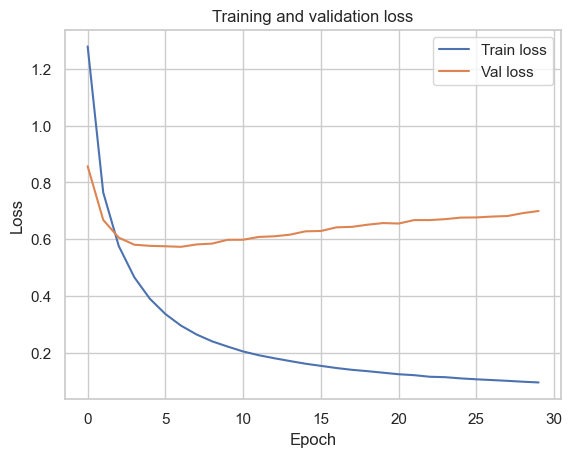

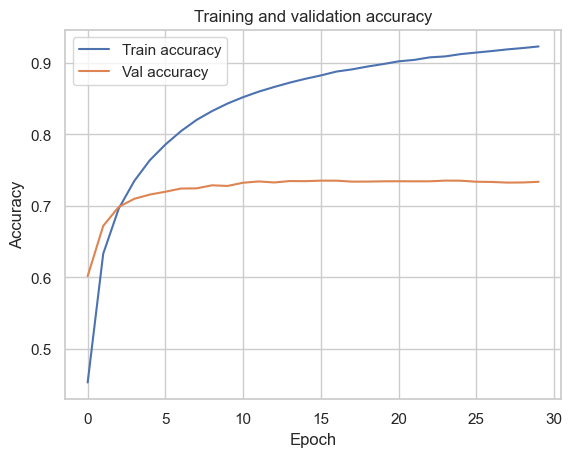

In [93]:
hist = history.history

epochs_range = range(len(hist["loss"]))

plt.figure()
plt.plot(epochs_range, hist["loss"], label="Train loss")
plt.plot(epochs_range, hist["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs_range, hist["accuracy"], label="Train accuracy")
plt.plot(epochs_range, hist["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

#### Reload model

In [94]:
# Reload best WORD-level model for evaluation
transformer_recon = keras.models.load_model(
    'models/transformer_word_best.keras',
    custom_objects={
        "PositionalEmbedding": PositionalEmbedding,
        "TransformerEncoder": TransformerEncoder,
        "TransformerDecoder": TransformerDecoder,
    },
)

transformer_recon.summary()

c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()`

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ english             │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ english[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dutch (InputLayer)  │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, None, 256) │  1,319,176 │ positional_embed… │
│ (TransformerEncode… │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_5         │ (None, None)      │          0 │ english[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, None, 256) │  3,845,120 │ dutch[0][0]       │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 256) │  1,582,856 │ transformer_enco… │
│ (TransformerDecode… │                   │            │ not_equal_5[0][0… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, None, 256) │          0 │ transformer_deco… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, None,      │  3,855,000 │ dropout_14[0][0]  │
│                     │ 15000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 43,341,818 (165.34 MB)

 Trainable params: 14,447,272 (55.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,894,546 (110.22 MB)

## Generate translation

In [95]:
# def decode_sequence(input_sentence):
#     tokenized_input_sentence = english_tokenizer([input_sentence])
#     decoded_sentence = "[start]"
#     for i in range(max_decoded_sentence_length):
#         tokenized_target_sentence = dutch_tokenizer([decoded_sentence])
#         next_token_predictions = transformer_recon.predict(
#             [tokenized_input_sentence, tokenized_target_sentence], verbose=0)
#         sampled_token_index = np.argmax(next_token_predictions[0, i, :])
#         sampled_token = dut_index_lookup[sampled_token_index]
#         decoded_sentence += " " + sampled_token
#         if sampled_token == "[end]":
#             break
#     return decoded_sentence

def generate_translation(input_sentence):
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(sequence_length):
        tokenized_target_sentence = dutch_tokenizer([decoded_sentence])
        tokenized_target_sentence = tokenized_target_sentence[:, :-1]
        inputs = [tokenized_input_sentence, tokenized_target_sentence]
        next_token_predictions = transformer_recon.predict(inputs, verbose=0)
        sampled_token_index = np.argmax(next_token_predictions[0, i, :])
        sampled_token = dut_index_lookup[sampled_token_index]
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence


#### Qualitative eval

In [96]:
zinnen = ["I heard it through the grapevine",
          "Sitting on the dock of the bay",
          "After laughter comes tears",
          "Do you like good music",
          "Stop, in the name of love",
          "I say a little prayer",
          "Ain't no mountain high enough",
          "you don't have to say you love me"]

m = len(max(zinnen, key=len))

for i in zinnen:
    j = math.ceil((m - len(i)-1)/8)+1
    tab = "".join(np.repeat("\t",j))
    print(i+tab+"-->" + "\t"+generate_translation(i))

I heard it through the grapevine	-->	[start] ik heb het voor het voorbereiden op het volume [end]
Sitting on the dock of the bay		-->	[start] op de catastrofe zitten we op de koelkast [end]
Sitting on the dock of the bay		-->	[start] op de catastrofe zitten we op de koelkast [end]
After laughter comes tears		-->	[start] na lachen komt lach of tranen [end]
Do you like good music			-->	[start] houdt u van goede muziek [end]
After laughter comes tears		-->	[start] na lachen komt lach of tranen [end]
Do you like good music			-->	[start] houdt u van goede muziek [end]
Stop, in the name of love		-->	[start] stop met de naam van de naam [end]
I say a little prayer			-->	[start] ik zeg een beetje kwestbaar [end]
Stop, in the name of love		-->	[start] stop met de naam van de naam [end]
I say a little prayer			-->	[start] ik zeg een beetje kwestbaar [end]
Ain't no mountain high enough		-->	[start] is niet genoeg berg genoeg [end]
Ain't no mountain high enough		-->	[start] is niet genoeg berg gen

#### Deel 1b
Bespreek de voor- en nadelen van de gebruikte dataset.

### Dataset algemeen

#### Voordelen
- De dataset is gratis en toegankelijk en veel gebruikt voor onderwijs en onderzoek
- De zinnen zijn kort wat geschikt en kunnen makkelijk ge-preprocessed worden en trainen snel
- De vertalingen zijn nagekeken door native speakers en de data is niet syntethisch
- De zinnen maken gebruik van natuurlijke taal ipv letterlijke vertalingen
- De dataset woordt nogsteeds uitgebreid door community contributions
- De data is gelabeled en heeft markers voor de start en eind positie

#### Nadelen dataset
- Vertaalkwaliteit is niet gegarandeert omdat de vertalingen door vrijwilligers gedaan zijn
- De data set kan fouten bevatten volgens de source
- Omdat de dataset gemaakt is met behulp van vrijwilligers kunnen er inconsistentisch zijn in vertalinge
- De betrouwbaarheid van de native speaker status is gebaseerd op vertrouwen
- Er zijn vernamelijk korte zinnen met beperkte taal variatie en grammaticale complexiteit
- Sommige zinnen komen uit de oude Tanaka corpus die onnatuurlijk klinkende of ouderwets klikende vertalingen bevat
- Er zijn geen labels voor dingen zoals dialect en onderwerp van de zin waardoor er minder mogelijkheid is voor intrepretatie
- De website zegd niks over de balans van het soort zinnen, er is mogelijk een over representatie van zinnen over specifieke onderwerpen

### Samengevat

De dataset is geschikt om snel een simpel model te maken voor vertalingen. Maar door gebrek aan variatie van de soorten zinnen, gelimiteerde zin lengte en complexiteit is de data mogelijk niet geschikt voor een real life vertalings probleem buiten het vertalen van simpele zinnen en onderwerpen.


### Deel 2
We willen dit model nu verbeteren. Bedenk een (mogelijke) verbetering. Het is niet de bedoeling dat je bestaande pretrained modellen gebruikt. Train alles zelf.

#### Deel 2a
Stel een korte lijst van eisen op waar jouw verbeterde model aan hoort te voldoen. 

#### Eisen voor het verbeterde model
- **Betere vertaalnauwkeurigheid**: merkbaar hogere kwaliteit op de validatieset vergeleken met het basismodel.
- **Robuustheid voor langere zinnen**: ondersteunt zinnen tot minimaal 30 tokens zonder sterke degradatie.
- **Stabiele training**: geen divergeren; verlies en accuracy bewegen consistent omlaag/omhoog gedurende epochs.
- **Beperkte modelcomplexiteit**: verbetering door gerichte aanpassing (geen drastische toename van parameters).
- **Meetbare verbetering**: scoreverbetering aangetoond met een erkende vertaalkwaliteitsmaat (BLEU).

#### Deel 2b
Licht het volgende toe:
- Welke verbetering je uitvoert en waarom je denkt dat dit voor een verbetering zal zorgen.
- Welke maat je gebruikt om de verbetering te meten, en waarom.

Houd je antwoorden kort en bondig.

#### Gekozen verbetering en maat
- **Verbetering**: verhoging van de maximale sequentielengte van 20 naar 30 tokens en toevoeging van een lichte label-smoothing (bijv. 0.1) in de loss. Dit vergroot de context die het model kan benutten en reduceert overconfident voorspellen, wat doorgaans tot betere generalisatie leidt.
- **Maat**: **BLEU-score** op de validatieset. BLEU is een breed geaccepteerde metriek in machinevertaling die n-gram overlap meet tussen de modeloutput en referentievertaling en daarmee geschikt is om kwalitatieve verbeteringen kwantitatief vast te leggen.

#### Deel 2c
Train dit verbeterde model.

In [97]:
import os
from pathlib import Path
import sentencepiece as spm
import numpy as np
import keras
from keras import layers, ops

# Reuse DATA_PATH and MODEL_DIR defined earlier
# Use a dedicated folder for SentencePiece artifacts and ensure it exists
out_dir = Path('sentence_piece')
out_dir.mkdir(parents=True, exist_ok=True)

# Keep sequence_length consistent with first iteration for fair comparison
vocab_size       = 15000
sequence_length  = 20
# Special token ids: chosen for simplicity and compatibility
pad_id           = 0  # padding = 0 enables simple masks (src != 0) and matches Keras defaults
# Note: SentencePiece reserves unk_id = 1 by default; we keep that convention
bos_id           = 2  # BOS placed at a low, fixed id after pad/unk for stable teacher forcing
eos_id           = 3  # EOS placed next to BOS for easy decoding/termination checks

In [98]:
tmp_eng = out_dir / "tmp_eng.txt"
tmp_nld = out_dir / "tmp_nld.txt"

# Reuse Part 1 variables directly
# For Dutch, strip special tokens for BPE to learn raw text
with open(tmp_eng, "w", encoding="utf-8") as f:
    f.write("\n".join(train_english_texts))
with open(tmp_nld, "w", encoding="utf-8") as f:
    f.write("\n".join([nl.replace('[start]', '').replace('[end]', '').strip() for nl in train_dutch_texts]))

spm.SentencePieceTrainer.Train(
    input=str(tmp_eng),
    model_prefix=str(out_dir / "sp_eng"),
    vocab_size=vocab_size,
    model_type="bpe",
    character_coverage=0.9995,
    pad_id=pad_id,
    unk_id=1,
    bos_id=bos_id,
    eos_id=eos_id,
)

spm.SentencePieceTrainer.Train(
    input=str(tmp_nld),
    model_prefix=str(out_dir / "sp_nld"),
    vocab_size=vocab_size,
    model_type="bpe",
    character_coverage=0.9995,
    pad_id=pad_id,
    unk_id=1,
    bos_id=bos_id,
    eos_id=eos_id,
)

sp_eng = spm.SentencePieceProcessor()
sp_nld = spm.SentencePieceProcessor()
sp_eng.Load(str(out_dir / "sp_eng.model"))
sp_nld.Load(str(out_dir / "sp_nld.model"))

print("SentencePiece models trained and loaded from:", out_dir)

SentencePiece models trained and loaded from: sentence_piece


In [99]:
# Build train/val/test lists using Part 1 variables
# Train: use train_english_texts/train_dutch_texts directly
train_en = train_english_texts
train_nl = [nl.replace('[start]', '').replace('[end]', '').strip() for nl in train_dutch_texts]

# Val/Test: derive from val_pairs to keep iteration 1 split logic
val_en = [en for en, nl in val_pairs]
val_nl = [nl.replace('[start]', '').replace('[end]', '').strip() for en, nl in val_pairs]

# If you need a test set, reuse remaining pairs from original split logic (optional)
# Here we keep it simple and focus on train/val
print(f"Train: {len(train_en)}, Val: {len(val_en)}")

Train: 58706, Val: 12579


In [100]:
def encode_batch_sp(src_texts, tgt_texts, sp_src, sp_tgt, max_len=sequence_length+1):
    src_ids = []
    tgt_ids = []
    for src, tgt in zip(src_texts, tgt_texts):
        # Source: no BOS/EOS to mirror iteration 1
        s_ids = sp_src.EncodeAsIds(src)
        # Target: BOS/EOS like iteration 1's [start]/[end]
        t_ids = [bos_id] + sp_tgt.EncodeAsIds(tgt) + [eos_id]

        # Truncate to desired max lengths (target is one token longer)
        s_ids = s_ids[:max_len-1]
        t_ids = t_ids[:max_len]

        # Pad to fixed lengths
        s_ids = s_ids + [pad_id] * ((max_len-1) - len(s_ids))
        t_ids = t_ids + [pad_id] * (max_len - len(t_ids))

        src_ids.append(s_ids)
        tgt_ids.append(t_ids)

    return np.array(src_ids, dtype=np.int32), np.array(tgt_ids, dtype=np.int32)

X_train, Y_train = encode_batch_sp(train_en, train_nl, sp_eng, sp_nld, max_len=sequence_length+1)
X_val,   Y_val   = encode_batch_sp(val_en,   val_nl,   sp_eng, sp_nld, max_len=sequence_length+1)

print("Encoded shapes ->",
      "X_train:", X_train.shape, "Y_train:", Y_train.shape,
      "X_val:", X_val.shape, "Y_val:", Y_val.shape)

# Prepare decoder input/output (teacher forcing), matching first iteration shapes
Y_train_in  = Y_train[:, :-1]
Y_train_out = Y_train[:, 1:]
Y_val_in    = Y_val[:, :-1]
Y_val_out   = Y_val[:, 1:]

Encoded shapes -> X_train: (58706, 20) Y_train: (58706, 21) X_val: (12579, 20) Y_val: (12579, 21)


In [101]:
# Save SentencePiece models to sentence_piece/
import os
from pathlib import Path
out_dir = Path('sentence_piece')
out_dir.mkdir(exist_ok=True)
eng_model_path = out_dir / 'english_bpe.model'
nld_model_path = out_dir / 'dutch_bpe.model'
# Write serialized model proto bytes
with open(eng_model_path, 'wb') as f:
    f.write(sp_eng.serialized_model_proto())
with open(nld_model_path, 'wb') as f:
    f.write(sp_nld.serialized_model_proto())
print('Saved SentencePiece models to', out_dir)

Saved SentencePiece models to sentence_piece


In [102]:
src_vocab_size = sp_eng.GetPieceSize()
tgt_vocab_size = sp_nld.GetPieceSize()

# Keep sequence_length FIXED to iteration 1 (no auto-adjust)
# sequence_length already set earlier to 20

# Build tf.data pipeline IDENTICAL to iteration 1 (batch/cache/prefetch)
batch_size = 64

# Prepare decoder input/output (teacher forcing), matching first iteration shapes
Y_train_in  = Y_train[:, :-1]
Y_train_out = Y_train[:, 1:]
Y_val_in    = Y_val[:, :-1]
Y_val_out   = Y_val[:, 1:]

def format_dataset_ids(src_ids, tgt_ids_in, tgt_ids_out):
    features = {
        "english": src_ids,
        "dutch": tgt_ids_in,  # decoder input (teacher forcing)
    }
    labels = tgt_ids_out
    sample_weights = labels != 0
    return features, labels, sample_weights

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train_in, Y_train_out))
train_ds = train_ds.batch(batch_size)
train_ds = train_ds.map(format_dataset_ids, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(2048).cache().prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val_in, Y_val_out))
val_ds = val_ds.batch(batch_size)
val_ds = val_ds.map(format_dataset_ids, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)

# Hyperparameters (reuse from iteration 1)
hidden_dim = 256
intermediate_dim = 2056
num_heads = 8

# Encoder (reuse PositionalEmbedding/TransformerEncoder from iteration 1)
src = keras.Input(shape=(None,), dtype="int32", name="english")
x_src = PositionalEmbedding(sequence_length, src_vocab_size, hidden_dim)(src)
enc_out = TransformerEncoder(hidden_dim, intermediate_dim, num_heads)(
    source=x_src,
    source_mask=src != 0,
)

# Decoder
tgt = keras.Input(shape=(None,), dtype="int32", name="dutch")
x_tgt = PositionalEmbedding(sequence_length, tgt_vocab_size, hidden_dim)(tgt)
dec_out = TransformerDecoder(hidden_dim, intermediate_dim, num_heads)(
    target=x_tgt,
    source=enc_out,
    source_mask=src != 0,
)

x = layers.Dropout(0.5)(dec_out)
logits = layers.Dense(tgt_vocab_size, activation="softmax")(x)

model = keras.Model(inputs=[src, tgt], outputs=logits)

# Compile identical to iteration 1 for fair comparison
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    weighted_metrics=["accuracy"],
)

# Callback: save best BPE model by validation loss
bpe_best_ckpt = keras.callbacks.ModelCheckpoint(
    filepath="models/transformer_bpe_best.keras",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[bpe_best_ckpt],
)

print("Training complete with SentencePiece BPE tokenization, training pipeline matches iteration 1.")

Epoch 1/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4174 - loss: 1.7630
Epoch 1: val_loss improved from None to 1.00193, saving model to models/transformer_bpe_best.keras

Epoch 1: val_loss improved from None to 1.00193, saving model to models/transformer_bpe_best.keras
918/918 ━━━━━━━━━━━━━━━━━━━━ 62s 68ms/step - accuracy: 0.5117 - loss: 1.3934 - val_accuracy: 0.6242 - val_loss: 1.0019
Epoch 2/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 62s 68ms/step - accuracy: 0.5117 - loss: 1.3934 - val_accuracy: 0.6242 - val_loss: 1.0019
Epoch 2/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6427 - loss: 0.9223
Epoch 2: val_loss improved from 1.00193 to 0.80580, saving model to models/transformer_bpe_best.keras

Epoch 2: val_loss improved from 1.00193 to 0.80580, saving model to models/transformer_bpe_best.keras
918/918 ━━━━━━━━━━━━━━━━━━━━ 68s 74ms/step - accuracy: 0.6637 - loss: 0.8484 - val_accuracy: 0.6812 - val_loss: 0.8058
Epoch 3/30
918/918 ━━━━━━━━━━━━━━━━━━━━ 68s 74ms/step 

### Rationale: Single-Change Improvement with BPE (SentencePiece)
- **Motivation**: Subword tokenization via BPE captures morphological structure and rare words better than word-level tokenization. It reduces out-of-vocabulary issues and improves sharing across related word forms.
- **Fair comparison**: We keep the model architecture, training loop, and hyperparameters the same. The only change is the tokenizer (Keras TextVectorization → SentencePiece BPE), so performance differences are attributable to tokenization.
- **Expectation**: Improved generalization on validation due to better handling of rare/compound words and consistent subword units, measured by BLEU.


In [103]:
# Reload best BPE model for evaluation
bpe_best_path = "models/transformer_bpe_best.keras"
try:
    model = keras.models.load_model(
        bpe_best_path,
        custom_objects={
            "PositionalEmbedding": PositionalEmbedding,
            "TransformerEncoder": TransformerEncoder,
            "TransformerDecoder": TransformerDecoder,
        },
    )
    print("Loaded best BPE model from:", bpe_best_path)
except Exception as e:
    print("Warning: could not load best BPE model; using in-memory model. Error:", e)

c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'positional_embedding_6', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'transformer_encoder_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\Frank\.conda\envs\nlp_cuda\Lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()`

Loaded best BPE model from: models/transformer_bpe_best.keras


#### Deel 3b
Bespreek het volgende.
- Hoeveel je model verbeterd (of verslechterd) is
- In het geval van geen verbetering, een mogelijke verklaring waarom het niet werkte.
- Licht toe wat je volgende stap zou zijn om betere resultaten te halen. Deze stap hoef je niet uit te voeren, maar wees wel specifiek en verantwoord het met jouw resultaten.

Houd je antwoorden kort en bondig.

> Jouw antwoord hier

### Evaluation: chrF++ (TorchMetrics)
We will compute chrF++ on the validation set using the trained model and greedy decoding. chrF++ is chrF with word n-grams enabled (set `word_order=2`).

In [122]:
# Install sacrebleu if not available
import importlib, sys, subprocess
try:
    import sacrebleu
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "sacrebleu"]) 
    import sacrebleu
print("sacrebleu version:", getattr(sacrebleu, "__version__", "unknown"))

sacrebleu version: 2.5.1


In [123]:
# chrF++ with sacrebleu only
import numpy as np
import math
from sacrebleu.metrics import CHRF

# True chrF++ (character + word n-grams)
chrf_metric = CHRF(word_order=2)

# Wrapper to keep existing call pattern
class SacreBLEUChrFWrapper:
    def __call__(self, preds, refs):
        res = chrf_metric.corpus_score(preds, [refs])
        class _Scalar:
            def item(self_inner):
                return res.score
        return _Scalar()

chrfpp = SacreBLEUChrFWrapper()
print("Using sacrebleu CHRF(word_order=2) for chrF++")

Using sacrebleu CHRF(word_order=2) for chrF++


In [124]:
# Helper: decode with the trained word-level tokenizer model (iteration 1)
# Uses `transformer_recon`, `english_tokenizer`, `dutch_tokenizer`, `dut_index_lookup`, and `sequence_length`.
def decode_iter1(input_sentence: str) -> str:
    tokenized_input_sentence = english_tokenizer([input_sentence])
    decoded_sentence = "[start]"
    for i in range(sequence_length):
        tokenized_target_sentence = dutch_tokenizer([decoded_sentence])
        tokenized_target_sentence = tokenized_target_sentence[:, :-1]
        next_token_predictions = transformer_recon.predict([tokenized_input_sentence, tokenized_target_sentence], verbose=0)
        sampled_token_index = int(np.argmax(next_token_predictions[0, i, :]))
        sampled_token = dut_index_lookup.get(sampled_token_index, "")
        decoded_sentence += " " + sampled_token
        if sampled_token == "[end]":
            break
    return decoded_sentence

In [128]:
# Prepare validation references and system outputs (fast subset + full)
# Slowdown note: per-sentence greedy decoding calls the model repeatedly.
# On CPU this is expensive. We first do a small subset sanity check, then (optionally) full.

# Small, fast sanity subset
N_SANITY = 16  # quick check size
test_subset = test_pairs[:N_SANITY]
references_subset = [nl.replace('[start]', '').replace('[end]', '').strip() for (en, nl) in test_subset]
hypotheses_subset = [decode_iter1(en).replace('[start]', '').replace('[end]', '').strip() for (en, nl) in test_subset]

# Show source, hypothesis, reference for first 3
preview = [(en, hyp, ref) for (en, _), hyp, ref in zip(test_subset[:3], hypotheses_subset[:3], references_subset[:3])]
print("Sanity examples (first 3) as (EN, HYP_NL, REF_NL):\n", preview)

# Optional: full set (can be slow on CPU). Comment/uncomment as needed.
RUN_FULL = False
if RUN_FULL:
    references = [nl.replace('[start]', '').replace('[end]', '').strip() for (en, nl) in test_pairs]
    hypotheses = [decode_iter1(en).replace('[start]', '').replace('[end]', '').strip() for (en, nl) in test_pairs]
    full_preview = [(en, hyp, ref) for (en, _), hyp, ref in zip(test_pairs[:3], hypotheses[:3], references[:3])]
    print("Full examples (first 3) as (EN, HYP_NL, REF_NL):\n", full_preview)


Sanity examples (first 3) as (EN, HYP_NL, REF_NL):
 [('Light the candle.', 'waarom zijn kaars', 'Steek de kaars aan.'), ("Let's pretend we're aliens.", 'laten we doen alsof we aliens zijn', 'Laten we doen alsof we buitenaardse wezens zijn.'), ('The soup is too salty.', 'de soep is te zout', 'De soep is te zout.')]


In [129]:
# Compute chrF++ (averaged over the corpus)
# Use full set if available; otherwise compute on the sanity subset
if 'RUN_FULL' in globals() and RUN_FULL and 'hypotheses' in globals() and 'references' in globals():
    score = float(chrfpp(hypotheses, references).item())
    print(f"chrF++ (full validation) : {score:.4f}")
else:
    score_subset = float(chrfpp(hypotheses_subset, references_subset).item())
    print(f"chrF++ (sanity subset {len(hypotheses_subset)}) : {score_subset:.4f}")


chrF++ (sanity subset 16) : 51.9351


Notes:
- chrF++ is sensitive to casing and punctuation; keep preprocessing consistent with training.
- For the BPE model, you can mirror this by adding a decode function that uses `sp_eng`/`sp_nld` and your BPE-trained model, then re-running the same evaluation block.

In [130]:
# BPE decode helper for SentencePiece model
# Uses `model` (BPE-trained Keras), `sp_eng`, `sp_nld`, BOS/EOS ids, and `sequence_length`.
# Greedy decoding similar to the word-level version.

def decode_bpe_iter2(input_sentence: str) -> str:
    # Encode English source with SentencePiece
    src_ids = sp_eng.EncodeAsIds(input_sentence)[:sequence_length]
    if len(src_ids) < sequence_length:
        src_ids = src_ids + [0] * (sequence_length - len(src_ids))  # pad_id = 0
    # Start Dutch decoding with BOS
    decoded_ids = [bos_id]
    for i in range(sequence_length):
        tgt_in = decoded_ids + [0] * max(0, sequence_length - len(decoded_ids))
        tgt_in = tgt_in[:sequence_length]
        # Prepare batch=1 inputs
        x_src = np.array([src_ids], dtype=np.int32)
        x_tgt = np.array([tgt_in], dtype=np.int32)
        # Predict next token distribution at position i
        probs = model.predict([x_src, x_tgt], verbose=0)
        next_id = int(np.argmax(probs[0, i, :]))
        decoded_ids.append(next_id)
        if next_id == eos_id:
            break
    # Remove BOS and EOS, decode to text
    clean_ids = [tid for tid in decoded_ids if tid not in (bos_id, eos_id, 0)]
    return sp_nld.DecodeIds(clean_ids)


In [131]:
# Final consolidated evaluation: chrF++ on test set, save results
import json
from pathlib import Path
import numpy as np

# Ensure sacrebleu CHRF++ is available (from earlier cell)
# chrfpp should already be defined as SacreBLEUChrFWrapper()

# Decoders defined earlier: generate_translation (word-level) and decode_bpe_iter2 (BPE)

def evaluate_models_on_pairs(pairs, max_examples=None):
    """
    Compute hypotheses and chrF++ scores for both models on given (EN, NL_with_markers) pairs.
    Returns dict with scores and samples.
    """
    if max_examples is not None:
        pairs = pairs[:max_examples]
    refs = [nl.replace('[start]', '').replace('[end]', '').strip() for (en, nl) in pairs]

    # Word-level hypotheses via Keras tokenizers
    hyps_word = []
    for en, _ in pairs:
        hyp = generate_translation(en).replace('[start]', '').replace('[end]', '').strip()
        hyps_word.append(hyp)

    # BPE hypotheses via SentencePiece
    hyps_bpe = []
    for en, _ in pairs:
        hyp = decode_bpe_iter2(en).strip()
        hyps_bpe.append(hyp)

    # chrF++ scores
    score_word = float(chrfpp(hyps_word, refs).item())
    score_bpe  = float(chrfpp(hyps_bpe,  refs).item())

    # Collect a few preview samples
    samples = []
    for i, (en, nl) in enumerate(pairs[:5]):
        samples.append({
            "en": en,
            "ref_nl": nl.replace('[start]', '').replace('[end]', '').strip(),
            "hyp_word": hyps_word[i],
            "hyp_bpe": hyps_bpe[i]
        })

    return {
        "count": len(pairs),
        "score_word_chrFpp": score_word,
        "score_bpe_chrFpp": score_bpe,
        "samples": samples
    }

# Choose test set for final evaluation (consistent with earlier split)
pairs_eval = test_pairs

# Limit evaluation size for speed on CPU
MAX_EXAMPLES = 256
results = evaluate_models_on_pairs(pairs_eval, max_examples=MAX_EXAMPLES)
print(f"chrF++ (word-level) test subset {results['count']}: {results['score_word_chrFpp']:.4f}")
print(f"chrF++ (BPE)        test subset {results['count']}: {results['score_bpe_chrFpp']:.4f}")

# Persist results to file
out_dir = Path('outputs')
out_dir.mkdir(parents=True, exist_ok=True)
json_path = out_dir / 'final_eval.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print('Saved final evaluation to', json_path)


chrF++ (word-level) test subset 256: 48.8866
chrF++ (BPE)        test subset 256: 58.5966
Saved final evaluation to outputs\final_eval.json


        model     chrF++
0  Word-level  48.886609
1         BPE  58.596560


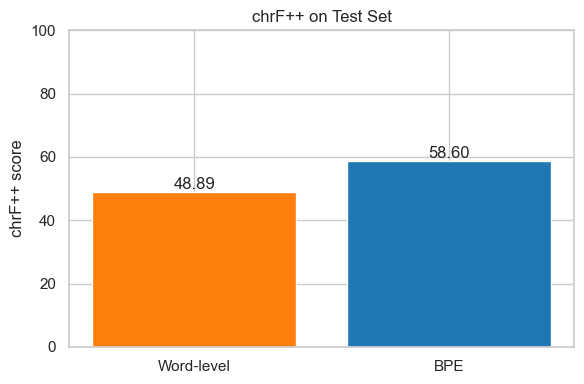


Sample comparisons (first 5):
EN: Light the candle.
REF: Steek de kaars aan.
WORD: waarom zijn kaars
BPE: Door de kaars.
-
EN: Let's pretend we're aliens.
REF: Laten we doen alsof we buitenaardse wezens zijn.
WORD: laten we doen alsof we aliens zijn
BPE: Laten we doen alsof we aliens zijn.
-
EN: The soup is too salty.
REF: De soep is te zout.
WORD: de soep is te zout
BPE: De soep is te zout.
-
EN: Tom is singing in French.
REF: Tom zingt in het Frans.
WORD: tom zingt in het frans
BPE: Tom is in het Frans aan het zingen.
-
EN: He's afraid of the sea.
REF: Hij is bang van de zee.
WORD: hij is bang voor de zee
BPE: Hij is bang voor de zee.
-
Winner by chrF++: BPE (Δ = 9.71)


In [132]:
# Final analysis and visuals using saved results
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Load results
json_path = Path('outputs/final_eval.json')
with open(json_path, 'r', encoding='utf-8') as f:
    res = json.load(f)

# Summary table
df = pd.DataFrame([
    {
        'model': 'Word-level',
        'chrF++': res['score_word_chrFpp']
    },
    {
        'model': 'BPE',
        'chrF++': res['score_bpe_chrFpp']
    }
], columns=['model','chrF++'])
print(df)

# Bar chart comparison
plt.figure(figsize=(6,4))
plt.bar(df['model'], df['chrF++'], color=['tab:orange','tab:blue'])
plt.title('chrF++ on Test Set')
plt.ylabel('chrF++ score')
plt.ylim(0, 100)
for i, v in enumerate(df['chrF++']):
    plt.text(i, v + 1, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()

# Preview a few samples
print("\nSample comparisons (first 5):")
for s in res.get('samples', []):
    print("EN:", s['en'])
    print("REF:", s['ref_nl'])
    print("WORD:", s['hyp_word'])
    print("BPE:", s['hyp_bpe'])
    print("-")

# Brief conclusion
better = 'BPE' if res['score_bpe_chrFpp'] > res['score_word_chrFpp'] else 'Word-level'
print(f"Winner by chrF++: {better} (Δ = {abs(res['score_bpe_chrFpp'] - res['score_word_chrFpp']):.2f})")